In [1]:
import os 
import cv2
import glob
import json
import torch
import torch.nn as nn
import torch.nn.functional as F

import einops
import random
import argparse
import numpy as np
import matplotlib.pyplot as plt

os.chdir('/root/autodl-tmp/omniHand')

from easydict import EasyDict as edict
from deepspeed.utils.zero_to_fp32 import load_state_dict_from_zero_checkpoint

torch.set_float32_matmul_precision('high')
torch.autograd.set_detect_anomaly(True)

from src.utils.io import load_yaml
from src.utils.tools import instantiate_from_config
from src.utils.plot import plot_hand_camera, plot_hand_subplot
import warnings
warnings.filterwarnings("ignore", message="The dataloader, train_dataloader, does not have many workers", category=UserWarning)
warnings.filterwarnings("ignore", message="The dataloader, val_dataloader, does not have many workers", category=UserWarning)

[2025-05-29 10:57:22,270] [INFO] [real_accelerator.py:239:get_accelerator] Setting ds_accelerator to cuda (auto detect)


/root/miniconda3/envs/mmhand/compiler_compat/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/root/miniconda3/envs/mmhand/compiler_compat/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status


In [3]:
args = edict({
    # 'config': 'config/omnihand_base_news.yaml',
    'config': 'config/omnihand_rtm_news.yaml',
    'world_size': 1,
    'rank': 0,
    'seed': 42,
    # 'resume_checkpoint': 'log/omnihand/omnihand-base-news-0527/last.ckpt',
    'resume_checkpoint': 'log/omnihand/omnihand-rtm-news-0528/last.ckpt',
})
cfg = load_yaml(args.config)

device = 'cuda'

# load data 
data_cfg = cfg.data_cfg
data_cfg.params.cfg.batch_size = 1
data = instantiate_from_config(data_cfg)
data.setup('fit')

# # set seed 
# set_seed(seed=args.seed, n_gpu=args.world_size)

# load model 
model_cfg = cfg.model_cfg
model_cfg.params.cfg.batch_size = 1
model = instantiate_from_config(model_cfg)
# Load checkpoint using the function provided by DeepSpeed
model.load_state_dict(torch.load(args.resume_checkpoint, weights_only=False)['state_dict'])

model = model.to(device).eval()
print('model loaded.')

model loaded.


In [6]:
# encoder = model.backbone
# torch.save(encoder.cpu().state_dict(), 'weights/rtm/model.pth')

In [6]:
def process_batch(batch, model, device='cuda'):
    """Process a batch of data through the model
    
    Args:
        batch: Dictionary containing input data
        model: OmniHand model instance
        device: Device to run on
        
    Returns:
        Dictionary containing processed joint points
    """
    # Move data to device and handle numpy arrays
    for key in batch:
        if isinstance(batch[key], np.ndarray):
            batch[key] = torch.tensor(batch[key]).unsqueeze(0).to(device)
        elif isinstance(batch[key], torch.Tensor):
            batch[key] = batch[key].unsqueeze(0).to(device)

    # Forward pass
    if data_cfg.params.cfg.opt.load_feature:
        features = batch['features']
    else:
        features = model.encode_feature(batch['joints'], batch['velocities'])

    # Get ground truth joints
    if hasattr(model.regressor, '_discretize_gt_poses'):
        batch = model._discretize_gt_poses(batch)
        joints = batch['joints_grid'].reshape(-1, 2, 24, 3)
    else: 
        joints = batch['joints']

    # Forward pass through regressor
    regressor_output = model.forward_feature(features)
    
    # Handle both SimCC and traditional decoder outputs
    if isinstance(regressor_output, tuple) and len(regressor_output) == 3:
        # SimCC decoder: decode coordinates from logits
        simcc_x, simcc_y, simcc_z = regressor_output
        joints_pred, _ = model.regressor.decode_keypoints(simcc_x, simcc_y, simcc_z)
        # Reshape to match ground truth format [B, 2, 24, 3]
        joints_pred = joints_pred.view(-1, 2, 24, 3)
    else:
        # Traditional decoder: direct coordinate output
        joints_pred = regressor_output

    # # <debug>
    # batch = model._discretize_gt_poses(batch)
    # joints_pred = batch['joints_grid'].reshape(-1, 2, 24, 3)
    # # </debug>

    # Calculate and print MPJPE
    valid_mask = ~torch.isnan(joints)
    joints_pred_ = joints_pred[valid_mask].reshape(-1, 3)   
    joints_ = joints[valid_mask].reshape(-1, 3)
    mpjpe = torch.norm(joints_pred_ - joints_, dim=-1).mean() * 1e3
    print(f'MPJPE: {mpjpe:.2f}')

    def get_points(joints):
        """Convert joint coordinates to points in millimeters"""
        points = joints[0].cpu().detach().numpy() * 1e3
        return points

    # Process left and right hands separately
    joints_l, joints_r = joints[:, 0], joints[:, 1]
    joints_pred_l, joints_pred_r = joints_pred[:, 0], joints_pred[:, 1]
    
    # Transform coordinates
    joints_points_l = get_points(joints_l)
    joints_points_r = get_points(joints_r)
    joints_pred_points_l = get_points(joints_pred_l)
    joints_pred_points_r = get_points(joints_pred_r)
    
    return {
        'joints_points_l': joints_points_l,
        'joints_points_r': joints_points_r,
        'joints_pred_points_l': joints_pred_points_l,
        'joints_pred_points_r': joints_pred_points_r,
        'mpjpe': mpjpe.item()
    }

MPJPE: 15.17


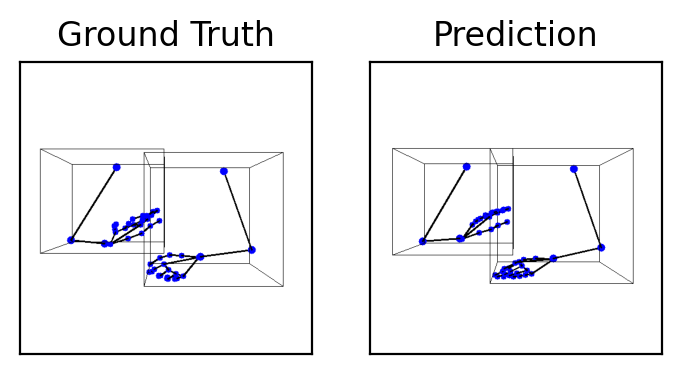

In [23]:
camera_params = {
    'camera_position': [0, 0, -1000],
    'camera_intrinsic': [800, 800, 256.0, 256.0]
}

batch = random.choice(data.val_dataset)
results = process_batch(batch, model, device)

plt.figure(dpi=200)
plot_hand_subplot(131, camera_params, results['joints_points_l'], results['joints_points_r'], 'Ground Truth')
plot_hand_subplot(132, camera_params, results['joints_pred_points_l'], results['joints_pred_points_r'], 'Prediction')
plt.show()